In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
df=pd.read_csv("powerplant_data.csv")

In [7]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [8]:
#AT => Temparature
#V => Vacuum
#AP => Pressure
#RH => Humidity
#PE => Produced Energy(Output)

In [10]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [11]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [37]:
import torch
import torch.nn as nn
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [26]:
type(X_train_scaled)

numpy.ndarray

In [27]:
type(y_train)

pandas.Series

In [34]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

## Deep Learning

In [43]:
#Define our ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            #1st hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
            #2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),
            #Output Layer
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)

In [44]:
import torch.optim as optim
model=ANN()
#loss,optimizer
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [47]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch
    
    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update
        
        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 196840.11380208333 & val loss = 184878.90625
epoch 2/100 ==> train loss = 161894.4144856771 & val loss = 133572.78125
epoch 3/100 ==> train loss = 102284.44825846354 & val loss = 73233.2734375
epoch 4/100 ==> train loss = 52877.39552408854 & val loss = 37481.7265625
epoch 5/100 ==> train loss = 28761.900463867187 & val loss = 22171.6875
epoch 6/100 ==> train loss = 18370.280000813804 & val loss = 15323.546875
epoch 7/100 ==> train loss = 13391.859962972005 & val loss = 11460.2216796875
epoch 8/100 ==> train loss = 9955.226285807292 & val loss = 8391.4462890625
epoch 9/100 ==> train loss = 7177.900520833334 & val loss = 5931.61279296875
epoch 10/100 ==> train loss = 5091.952037556966 & val loss = 4238.90380859375
epoch 11/100 ==> train loss = 3687.6885991414388 & val loss = 3110.173583984375
epoch 12/100 ==> train loss = 2758.302332051595 & val loss = 2339.467529296875
epoch 13/100 ==> train loss = 2099.707467397054 & val loss = 1783.295654296875
epoch 14/10

Matplotlib is building the font cache; this may take a moment.


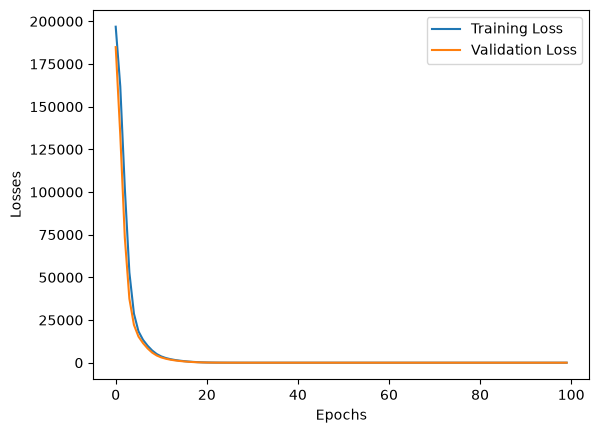

In [50]:

import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [51]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [53]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.334287643432617
Testing MSE: 18.65997314453125


In [54]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9347882089153179


In [55]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.094360,433.27
1,437.012756,438.16
2,461.219269,458.42
3,476.324402,480.82
4,435.192200,441.41
...,...,...
1909,451.331268,456.70
1910,431.583130,438.04
1911,467.513367,467.80
1912,431.063263,437.14
